# 🌿 HSI Tree Crown Segmentation — 3D CNN from Scratch

**Pipeline:**
1. **HSI Preprocessing** (one-time): scale reflectance, remove water bands, Savitzky-Golay smoothing, save as `.tif`
2. **3D CNN U-Net**: joint spectral-spatial feature extraction
3. **HSI augmentation**: spectral jitter, band dropout, spatial flips

**Data:**
- HSI cubes: `B × 32 × 32` `.tif` (B = 426 or 360 bands)
- Labels: `32 × 32` `.tif` — your georeferenced downsampled masks `{0, 1}`
- ~6k training patches

## 📦 Cell 1 — Installs & Imports

In [1]:
# !pip install torch torchvision scipy numpy matplotlib tqdm wandb python-dotenv
# !pip install rasterio tifffile imagecodecs

import os
import random
import shutil
import datetime
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import rasterio
import tifffile
from scipy.signal import savgol_filter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# from dotenv import load_dotenv
import wandb

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Using device: cuda
   GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## ⚙️ Cell 2 — Configuration

In [2]:
# ── wandb login ───────────────────────────────────────────────────────────────
# load_dotenv('../neon-tree-species/.env')
# api_key = os.getenv('WANDB_API_KEY')

if wandb.run is not None:
    wandb.finish()
wandb.login() #key=api_key

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/echerif/.netrc.


wandb: Currently logged in as: eya-cherif14 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [22]:
run_label = 'hsi_3dcnn_baseline'
run_id    = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

CFG = {
    # ── Paths ──────────────────────────────────────────────────────────
    # Raw HSI patches + your georeferenced downsampled labels
    'hsi_root'        : '../data/splits/hsi_binary',
    # Where preprocessed cubes are saved (one-time)
    'preprocessed_dir': '../data/hsi_preprocessed',
    # Run checkpoints
    'save_dir'        : f'../neon-tree-species/run_{run_id}_{run_label}/checkpoints',

    # ── Spectral preprocessing ─────────────────────────────────────────
    'n_bands_raw'   : 426,    # your sensor band count (426 or 360)
    'sg_window'     : 11,     # Savitzky-Golay window (must be odd)
    'sg_polyorder'  : 3,      # Savitzky-Golay polynomial order

    # ── Model ──────────────────────────────────────────────────────────
    'img_size'      : 32,     # HSI spatial size
    'base_channels' : 16,     # 3D CNN is memory-heavy; start small

    # ── Training ───────────────────────────────────────────────────────
    'epochs'        : 100,
    'batch_size'    : 16,
    'lr'            : 1e-3,
    'weight_decay'  : 1e-4,
    'num_workers'   : 2,

    # ── Loss ───────────────────────────────────────────────────────────
    'focal_gamma'   : 2.0,
    'pos_weight'    : 2.0,
    'dice_weight'   : 0.5,
}

os.makedirs(CFG['save_dir'], exist_ok=True)
os.makedirs(CFG['preprocessed_dir'], exist_ok=True)

In [23]:
wandb.init(
    project = 'tree-crown-segmentation',
    name    = f'run_{run_id}_{run_label}',
    config  = CFG,
)
print(f'✅ Config ready | wandb: {wandb.run.url}')

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


✅ Config ready | wandb: https://wandb.ai/eya-cherif14/tree-crown-segmentation/runs/2ncm77ze


## 🧹 Cell 3 — HSI Preprocessing (Run Once!)

Cleans raw HSI cubes and saves as `.tif`. Labels are **copied as-is** — already correctly georeferenced and downsampled with `Resampling.nearest`.

Steps on cubes only:
1. Scale NEON reflectance ÷10000 → [0, 1]
2. Remove water absorption bands (1340–1445nm, 1790–1955nm, 2450–2510nm)
3. Clip to 400–2450nm
4. Savitzky-Golay smoothing along spectral axis
5. Per-patch normalization to [0, 1]

In [12]:
# ── Spectral band removal config ──────────────────────────────────────────────
WATER_BANDS = [
    (1340, 1445),   # water vapour 1
    (1790, 1955),   # water vapour 2
    (2450, 2510),   # end of sensor range
]
WL_MIN = 400
WL_MAX = 2450


In [ ]:
####

def get_band_mask(wl):
    """Boolean array — True = keep this band."""
    bad = np.zeros(len(wl), dtype=bool)
    for lo, hi in WATER_BANDS:
        bad |= (wl >= lo) & (wl <= hi)
    bad |= (wl < WL_MIN) | (wl > WL_MAX)
    return ~bad


def preprocess_cube(cube, band_mask, sg_window=11, sg_polyorder=3):
    """
    cube      : (B, H, W) float32  raw NEON data
    band_mask : (B,) bool
    Returns   : (B_clean, H, W) float32
    """
    # Scale NEON AOP reflectance (stored x10000)
    cube = cube / 10000.0
    cube = np.clip(cube, 0, 1)

    # Select valid bands
    cube = cube[band_mask]              # (B_clean, H, W)
    B_clean, H, W = cube.shape

    # Savitzky-Golay smoothing along spectral axis
    cube_flat = cube.reshape(B_clean, -1)   # (B_clean, H*W)
    cube_flat = savgol_filter(
        cube_flat,
        window_length = sg_window,
        polyorder     = sg_polyorder,
        axis          = 0
    )
    cube = cube_flat.reshape(B_clean, H, W)

    # Per-patch normalization
    mn, mx = cube.min(), cube.max()
    if mx > mn:
        cube = (cube - mn) / (mx - mn)

    return cube.astype(np.float32)


def run_hsi_preprocessing(cfg):
    hsi_root = Path(cfg['hsi_root'])
    out_root = Path(cfg['preprocessed_dir'])
    N_BANDS_CLEAN = None

    for split in ['train', 'val', 'test']:
        hsi_img_dir = hsi_root / split / 'img'    / 'tree'
        hsi_lbl_dir = hsi_root / split / 'labels' / 'tree'
        out_img_dir = out_root / split / 'img'    / 'tree'
        out_lbl_dir = out_root / split / 'labels' / 'tree'
        out_img_dir.mkdir(parents=True, exist_ok=True)
        out_lbl_dir.mkdir(parents=True, exist_ok=True)

        hsi_paths = sorted(hsi_img_dir.glob('*.tif'))
        lbl_paths = sorted(hsi_lbl_dir.glob('*.tif'))

        assert len(hsi_paths) == len(lbl_paths) > 0, \
            f'{split}: count mismatch — {len(hsi_paths)} cubes vs {len(lbl_paths)} labels'

        print(f'\n📂 {split}: {len(hsi_paths)} patches')
        processed = skipped = 0

        for hsi_path, lbl_path in tqdm(zip(hsi_paths, lbl_paths),
                                       total=len(hsi_paths), desc=f'  {split}'):

            # Safety: names must match
            assert hsi_path.stem == lbl_path.stem, \
                f'Name mismatch: {hsi_path.stem} vs {lbl_path.stem}'

            out_cube_path = out_img_dir / hsi_path.name
            out_mask_path = out_lbl_dir / lbl_path.name

            if out_cube_path.exists() and out_mask_path.exists():
                skipped += 1
                continue

            # ── Preprocess cube ───────────────────────────────────────────
            with rasterio.open(hsi_path) as src:
                cube = src.read().astype(np.float32)   # (B, H, W)
            B, H, W   = cube.shape
            wl        = np.linspace(380, 2510, B)
            band_mask = get_band_mask(wl)

            if N_BANDS_CLEAN is None:
                N_BANDS_CLEAN = int(band_mask.sum())
                print(f'  Bands    : {B} raw -> {N_BANDS_CLEAN} clean '
                      f'(removed {B - N_BANDS_CLEAN} water/edge bands)')
                print(f'  WL range : {wl[band_mask].min():.0f}–'
                      f'{wl[band_mask].max():.0f} nm')

            cube_clean = preprocess_cube(
                cube, band_mask,
                cfg['sg_window'], cfg['sg_polyorder']
            )
            tifffile.imwrite(out_cube_path, cube_clean)  # (B_clean, H, W) float32

            # ── Label: copy as-is ─────────────────────────────────────────
            # Already georeferenced + downsampled with Resampling.nearest
            shutil.copy2(lbl_path, out_mask_path)
            processed += 1

        print(f'  ✅ {processed} processed | {skipped} skipped')

    return N_BANDS_CLEAN


In [ ]:
# N_BANDS_CLEAN = run_hsi_preprocessing(CFG)
# print(f'\n🔢 N_BANDS_CLEAN = {N_BANDS_CLEAN}  <- used as model input')


📂 train: 5945 patches


  train:   0%|          | 0/5945 [00:00<?, ?it/s]

  Bands    : 426 raw -> 356 clean (removed 70 water/edge bands)
  WL range : 400–2450 nm


  train: 100%|██████████| 5945/5945 [11:29<00:00,  8.63it/s]


  ✅ 5945 processed | 0 skipped

📂 val: 1272 patches


  val: 100%|██████████| 1272/1272 [01:59<00:00, 10.65it/s]


  ✅ 1272 processed | 0 skipped

📂 test: 1278 patches


  test: 100%|██████████| 1278/1278 [01:56<00:00, 11.00it/s]

  ✅ 1278 processed | 0 skipped

🔢 N_BANDS_CLEAN = 356  <- used as model input


## 🔍 Cell 4 — Verify Preprocessing

Cube : shape=(356, 32, 32)  dtype=float32  min=0.000  max=1.000
Mask : shape=(32, 32)  dtype=uint8  unique=[0 1]  tree%=0.484
train: 5945 patches | all-bg=0 | tree% min=0.009 max=0.771 avg=0.370
val  : 1272 patches | all-bg=0 | tree% min=0.074 max=0.863 avg=0.645
test : 1278 patches | all-bg=0 | tree% min=0.090 max=0.848 avg=0.617


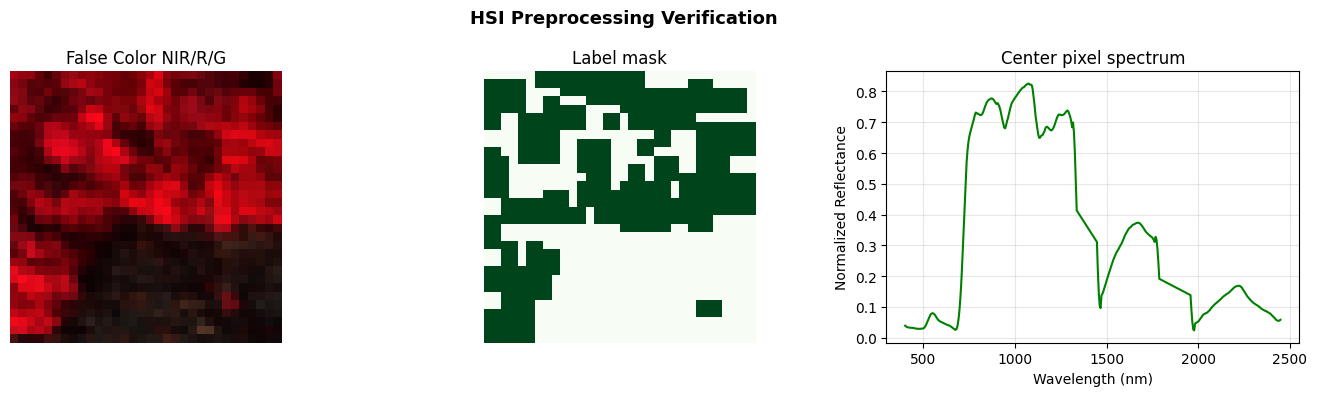

In [7]:
out_root = Path(CFG['preprocessed_dir'])

# ── One cube + mask ───────────────────────────────────────────────────────────
sample_cube = tifffile.imread(sorted((out_root / 'train' / 'img'    / 'tree').glob('*.tif'))[0])
sample_mask = tifffile.imread(sorted((out_root / 'train' / 'labels' / 'tree').glob('*.tif'))[0])
print(f'Cube : shape={sample_cube.shape}  dtype={sample_cube.dtype}  min={sample_cube.min():.3f}  max={sample_cube.max():.3f}')
print(f'Mask : shape={sample_mask.shape}  dtype={sample_mask.dtype}  unique={np.unique(sample_mask)}  tree%={sample_mask.mean():.3f}')

# ── Mask stats across splits ──────────────────────────────────────────────────
for split in ['train', 'val', 'test']:
    mask_paths = sorted((out_root / split / 'labels' / 'tree').glob('*.tif'))
    ratios     = [tifffile.imread(p).mean() for p in mask_paths[:50]]
    all_bg     = sum(1 for r in ratios if r == 0)
    print(f'{split:5s}: {len(mask_paths)} patches | all-bg={all_bg} | '
          f'tree% min={min(ratios):.3f} max={max(ratios):.3f} avg={np.mean(ratios):.3f}')

# ── Visualize: false color + mask + spectrum ──────────────────────────────────
wl_all   = np.linspace(380, 2510, CFG['n_bands_raw'])
wl_clean = wl_all[get_band_mask(wl_all)]
nir_idx  = int(np.argmin(np.abs(wl_clean - 850)))
red_idx  = int(np.argmin(np.abs(wl_clean - 670)))
grn_idx  = int(np.argmin(np.abs(wl_clean - 550)))

fc = np.stack([sample_cube[nir_idx], sample_cube[red_idx], sample_cube[grn_idx]], axis=-1)
fc = (fc - fc.min()) / (fc.max() - fc.min() + 1e-6)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(fc);  axes[0].set_title('False Color NIR/R/G'); axes[0].axis('off')
axes[1].imshow(sample_mask, cmap='Greens', vmin=0, vmax=1)
axes[1].set_title('Label mask'); axes[1].axis('off')
px = sample_cube[:, sample_cube.shape[1]//2, sample_cube.shape[2]//2]
axes[2].plot(wl_clean, px, color='green', lw=1.5)
axes[2].set_title('Center pixel spectrum'); axes[2].set_xlabel('Wavelength (nm)')
axes[2].set_ylabel('Normalized Reflectance'); axes[2].grid(alpha=0.3)

plt.suptitle('HSI Preprocessing Verification', fontsize=13, fontweight='bold')

plt.tight_layout()
# plt.savefig('hsi_preprocessing_check.png', dpi=120, bbox_inches='tight')
plt.show()

## 🎨 Cell 5 — HSI Dataset & Augmentation

HSI augmentation differs from RGB:
- ✅ Spatial flips/rotations — canopy is orientation-invariant
- ✅ Spectral jitter — simulates sensor gain variation per band
- ✅ Band dropout — forces model not to rely on single bands
- ✅ Spectral shift — simulates illumination/atmospheric variation
- ❌ No color jitter — spectral shape is physically meaningful

In [17]:
class HSIAugmentation:
    """
    HSI-specific augmentation for (B, H, W) cubes.
    Spatial transforms: applied to both cube and mask.
    Spectral transforms: applied to cube only.
    """
    def __init__(self, is_train=True,
                 p_flip=0.5, p_rot=0.5,
                 p_spectral_jitter=0.5,
                 p_band_dropout=0.3,
                 p_spectral_shift=0.3):
        self.is_train          = is_train
        self.p_flip            = p_flip
        self.p_rot             = p_rot
        self.p_spectral_jitter = p_spectral_jitter
        self.p_band_dropout    = p_band_dropout
        self.p_spectral_shift  = p_spectral_shift

    def __call__(self, cube, mask):
        if not self.is_train:
            return cube, mask

        # ── Spatial (cube and mask together) ──────────────────────────
        if random.random() < self.p_flip:        # horizontal
            cube = cube[:, :, ::-1].copy()
            mask = mask[:, ::-1].copy()
        if random.random() < self.p_flip:        # vertical
            cube = cube[:, ::-1, :].copy()
            mask = mask[::-1, :].copy()
        if random.random() < self.p_rot:         # 90/180/270
            k    = random.randint(1, 3)
            cube = np.rot90(cube, k, axes=(1, 2)).copy()
            mask = np.rot90(mask, k, axes=(0, 1)).copy()

        # ── Spectral (cube only) ──────────────────────────────────────
        if random.random() < self.p_spectral_jitter:
            gain = np.random.normal(1.0, 0.02,
                                    size=(cube.shape[0], 1, 1)).astype(np.float32)
            cube = np.clip(cube * gain, 0, 1)

        if random.random() < self.p_band_dropout:
            n_drop   = random.randint(1, max(1, cube.shape[0] // 20))
            drop_idx = random.sample(range(cube.shape[0]), n_drop)
            cube[drop_idx] = 0.0

        if random.random() < self.p_spectral_shift:
            cube = np.clip(cube + np.random.uniform(-0.05, 0.05), 0, 1)

        return cube, mask


class HSIDataset(Dataset):
    """
    Loads preprocessed HSI cubes and binary masks — both .tif.
    Masks are already binary {0,1} — just cast to float32, no binarization.
    """
    def __init__(self, cube_paths, mask_paths, augmentation=None):
        self.cube_paths   = cube_paths
        self.mask_paths   = mask_paths
        self.augmentation = augmentation

    def __len__(self):
        return len(self.cube_paths)

    def __getitem__(self, idx):
        cube = tifffile.imread(self.cube_paths[idx]).astype(np.float32)  # (B, H, W)
        mask = tifffile.imread(self.mask_paths[idx]).astype(np.float32)  # (H, W) already {0,1}

        if self.augmentation:
            cube, mask = self.augmentation(cube, mask)

        return torch.from_numpy(cube), torch.from_numpy(mask).unsqueeze(0)


def build_hsi_dataloaders(cfg):
    root = Path(cfg['preprocessed_dir'])

    train_cubes = sorted((root / 'train' / 'img'    / 'tree').glob('*.tif'))
    train_masks = sorted((root / 'train' / 'labels' / 'tree').glob('*.tif'))
    val_cubes   = sorted((root / 'val'   / 'img'    / 'tree').glob('*.tif'))
    val_masks   = sorted((root / 'val'   / 'labels' / 'tree').glob('*.tif'))

    assert len(train_cubes) == len(train_masks) > 0, \
        f'Train mismatch: {len(train_cubes)} vs {len(train_masks)}'
    assert len(val_cubes) == len(val_masks) > 0, \
        f'Val mismatch: {len(val_cubes)} vs {len(val_masks)}'

    train_ds = HSIDataset(train_cubes, train_masks,
                          augmentation=HSIAugmentation(is_train=True))
    val_ds   = HSIDataset(val_cubes,   val_masks,
                          augmentation=HSIAugmentation(is_train=False))

    train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'],
                              shuffle=True,  num_workers=cfg['num_workers'],
                              pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=cfg['batch_size'],
                              shuffle=False, num_workers=cfg['num_workers'],
                              pin_memory=True)

    print(f'✅ Train: {len(train_ds)} | Val: {len(val_ds)}')
    return train_loader, val_loader


print('✅ Dataset & augmentation ready.')

✅ Dataset & augmentation ready.


## 🧠 Cell 6 — 3D CNN U-Net

3D convolutions extract **joint spectral-spatial** features simultaneously.  
Pooling is **spatial-only** `(1,2,2)` — preserves spectral resolution through encoding.  
SpectralAttention learns which bands are most diagnostic (NIR, red edge for vegetation).

In [ ]:
N_BANDS_CLEAN = 356

class Conv3DBlock(nn.Module):
    """3D Conv -> BN -> ReLU x2. kernel=(spectral_k, 3, 3)"""
    def __init__(self, in_ch, out_ch, spectral_k=7, dropout=0.1):
        super().__init__()
        pad = (spectral_k // 2, 1, 1)
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=(spectral_k, 3, 3),
                      padding=pad, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout3d(dropout),
            nn.Conv3d(out_ch, out_ch, kernel_size=(spectral_k, 3, 3),
                      padding=pad, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class SpectralAttention(nn.Module):
    """Per-band sigmoid attention — learns which bands matter most."""
    def forward(self, x):
        attn = x.mean(dim=1).mean(dim=(-2, -1))   # (B, D)
        attn = torch.sigmoid(attn).unsqueeze(1).unsqueeze(-1).unsqueeze(-1)  # (B,1,D,1,1)
        return x * attn


class HSI3DUNet(nn.Module):
    """
    3D CNN U-Net for HSI binary segmentation.
    Input  : (B, n_bands, H, W)
    Output : (B, 1, H, W) logits
    """
    def __init__(self, n_bands, out_channels=1, base_channels=16):
        super().__init__()
        b = base_channels

        # 3D Encoder — spectral kernel shrinks deeper
        self.enc1 = Conv3DBlock(1,   b,   spectral_k=7, dropout=0.1)
        self.enc2 = Conv3DBlock(b,   b*2, spectral_k=5, dropout=0.1)
        self.enc3 = Conv3DBlock(b*2, b*4, spectral_k=3, dropout=0.2)

        # Spatial-only pooling — preserve spectral dimension
        self.pool = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))

        self.spectral_attn     = SpectralAttention()
        self.spectral_collapse = nn.AdaptiveAvgPool3d((1, None, None))

        # 2D Decoder
        self.dec2     = self._conv2d_block(b*4 + b*2, b*2, dropout=0.2)
        self.dec1     = self._conv2d_block(b*2 + b,   b,   dropout=0.1)
        self.out_conv = nn.Conv2d(b, out_channels, kernel_size=1)

    def _conv2d_block(self, in_ch, out_ch, dropout=0.0):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True), nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def _collapse(self, x):
        """(B, C, D, H, W) -> (B, C, H, W)"""
        return self.spectral_collapse(x).squeeze(2)

    def forward(self, x):
        x  = x.unsqueeze(1)             # (B, 1, n_bands, H, W)
        e1 = self.enc1(x)               # (B, b,   n_bands, H,   W  )
        e2 = self.enc2(self.pool(e1))   # (B, b*2, n_bands, H/2, W/2)
        e3 = self.enc3(self.pool(e2))   # (B, b*4, n_bands, H/4, W/4)
        e3 = self.spectral_attn(e3)
        d3 = self._collapse(e3)         # (B, b*4, H/4, W/4)
        s2 = self._collapse(e2)         # (B, b*2, H/2, W/2)
        s1 = self._collapse(e1)         # (B, b,   H,   W  )
        d2 = F.interpolate(d3, size=s2.shape[2:], mode='bilinear', align_corners=False)
        d2 = self.dec2(torch.cat([d2, s2], dim=1))
        d1 = F.interpolate(d2, size=s1.shape[2:], mode='bilinear', align_corners=False)
        d1 = self.dec1(torch.cat([d1, s1], dim=1))
        return self.out_conv(d1)        # (B, 1, H, W)


# ── Sanity check ──────────────────────────────────────────────────────────────
model = HSI3DUNet(n_bands=N_BANDS_CLEAN, base_channels=CFG['base_channels']).to(DEVICE)
dummy = torch.randn(2, N_BANDS_CLEAN, CFG['img_size'], CFG['img_size']).to(DEVICE)
out   = model(dummy)
print(f'✅ Input : {dummy.shape}')
print(f'✅ Output: {out.shape}')   # expect [2, 1, 32, 32]
print(f'✅ Params: {sum(p.numel() for p in model.parameters()):,}')

✅ Input : torch.Size([2, 356, 32, 32])
✅ Output: torch.Size([2, 1, 32, 32])
✅ Params: 298,881


## ⚖️ Cell 7 — Loss & Metrics

In [19]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=1.0):
        super().__init__()
        self.gamma      = gamma
        self.pos_weight = torch.tensor([pos_weight])
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight.to(logits.device))
        return ((1 - torch.exp(-bce)) ** self.gamma * bce).mean()

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        tgts  = targets.view(-1)
        inter = (probs * tgts).sum()
        return 1 - (2. * inter + self.smooth) / (probs.sum() + tgts.sum() + self.smooth)

class CombinedLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=1.0, dice_weight=0.5):
        super().__init__()
        self.focal       = FocalLoss(gamma, pos_weight)
        self.dice        = DiceLoss()
        self.dice_weight = dice_weight
    def forward(self, logits, targets):
        return ((1 - self.dice_weight) * self.focal(logits, targets) +
                      self.dice_weight * self.dice(logits, targets))

def compute_iou(preds, targets, threshold=0.5, eps=1e-6):
    if targets.sum() == 0 and (torch.sigmoid(preds) > threshold).sum() == 0:
        return float('nan')
    preds = (torch.sigmoid(preds) > threshold).float()
    inter = (preds * targets).sum()
    union = preds.sum() + targets.sum() - inter
    return ((inter + eps) / (union + eps)).item()

def compute_dice(preds, targets, threshold=0.5, eps=1e-6):
    if targets.sum() == 0 and (torch.sigmoid(preds) > threshold).sum() == 0:
        return float('nan')
    preds = (torch.sigmoid(preds) > threshold).float()
    inter = (preds * targets).sum()
    return ((2 * inter + eps) / (preds.sum() + targets.sum() + eps)).item()

print('✅ Loss & metrics ready.')

✅ Loss & metrics ready.


## 🚂 Cell 8 — Training & Validation Loops

In [21]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_iou, total_dice, n_valid = 0., 0., 0., 0
    for cubes, masks in tqdm(loader, desc='  Train', leave=False):
        cubes = cubes.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(cubes)
        loss   = criterion(logits, masks)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        iou = compute_iou(logits.detach(), masks)
        if not np.isnan(iou):
            total_iou  += iou
            total_dice += compute_dice(logits.detach(), masks)
            n_valid    += 1
    n = len(loader)
    return total_loss/n, total_iou/max(n_valid,1), total_dice/max(n_valid,1)

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, total_iou, total_dice, n_valid = 0., 0., 0., 0
    for cubes, masks in tqdm(loader, desc='  Val  ', leave=False):
        cubes = cubes.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(cubes)
        loss   = criterion(logits, masks)
        total_loss += loss.item()
        iou = compute_iou(logits, masks)
        if not np.isnan(iou):
            total_iou  += iou
            total_dice += compute_dice(logits, masks)
            n_valid    += 1
    n = len(loader)
    return total_loss/n, total_iou/max(n_valid,1), total_dice/max(n_valid,1)

print('✅ Training loops ready.')

✅ Training loops ready.


## 🏋️ Cell 9 — Run Training

In [24]:
# ── Build everything ──────────────────────────────────────────────────────────
train_loader, val_loader = build_hsi_dataloaders(CFG)

model = HSI3DUNet(
    n_bands       = N_BANDS_CLEAN,
    base_channels = CFG['base_channels']
).to(DEVICE)

criterion = CombinedLoss(
    gamma       = CFG['focal_gamma'],
    pos_weight  = CFG['pos_weight'],
    dice_weight = CFG['dice_weight']
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = CFG['lr'],
    weight_decay = CFG['weight_decay']
)

from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
warmup_scheduler = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=CFG['epochs']-5, eta_min=1e-6)
scheduler        = SequentialLR(optimizer,
                                schedulers=[warmup_scheduler, cosine_scheduler],
                                milestones=[5])

# ── Precompute false-color band indices for wandb visualization ───────────────
wl_all   = np.linspace(380, 2510, CFG['n_bands_raw'])
wl_clean = wl_all[get_band_mask(wl_all)]
nir_idx  = int(np.argmin(np.abs(wl_clean - 850)))
red_idx  = int(np.argmin(np.abs(wl_clean - 670)))
grn_idx  = int(np.argmin(np.abs(wl_clean - 550)))

# ── Training loop ─────────────────────────────────────────────────────────────
history = {'train_loss':[], 'val_loss':[], 'train_iou':[], 'val_iou':[],
           'train_dice':[], 'val_dice':[]}

best_val_iou = 0.0
patience_cnt = 0
PATIENCE     = 20

print(f'🚀 Starting HSI training for {CFG["epochs"]} epochs...\n')

for epoch in range(1, CFG['epochs'] + 1):
    tr_loss, tr_iou, tr_dice = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE)
    va_loss, va_iou, va_dice = validate(
        model, val_loader, criterion, DEVICE)

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_iou'].append(tr_iou)
    history['val_iou'].append(va_iou)
    history['train_dice'].append(tr_dice)
    history['val_dice'].append(va_dice)

    lr_now = optimizer.param_groups[0]['lr']
    print(f'Epoch [{epoch:03d}/{CFG["epochs"]}]  '
          f'Loss: {tr_loss:.4f}/{va_loss:.4f}  '
          f'IoU: {tr_iou:.3f}/{va_iou:.3f}  '
          f'Dice: {tr_dice:.3f}/{va_dice:.3f}  '
          f'LR: {lr_now:.2e}')

    # ── wandb scalars ──────────────────────────────────────────────────
    wandb.log({
        'epoch'      : epoch, 'lr': lr_now,
        'train/loss' : tr_loss, 'train/iou': tr_iou, 'train/dice': tr_dice,
        'val/loss'   : va_loss, 'val/iou':   va_iou, 'val/dice':   va_dice,
    })

    # ── wandb images every 10 epochs ───────────────────────────────────
    if epoch % 10 == 0:
        model.eval()
        cubes, msks = next(iter(val_loader))
        with torch.no_grad():
            lgts = model(cubes.to(DEVICE))
            prds = (torch.sigmoid(lgts) > 0.5).float()
        wandb_images = []
        for i in range(min(4, len(cubes))):
            cube_np = cubes[i].cpu().numpy()
            fc = np.stack([cube_np[nir_idx], cube_np[red_idx], cube_np[grn_idx]], axis=-1)
            fc = (fc - fc.min()) / (fc.max() - fc.min() + 1e-6)
            wandb_images.append(wandb.Image(
                fc,
                masks={
                    'ground_truth': {'mask_data': msks[i,0].numpy(),
                                     'class_labels': {0:'bg', 1:'tree'}},
                    'prediction'  : {'mask_data': prds[i,0].cpu().numpy(),
                                     'class_labels': {0:'bg', 1:'tree'}},
                },
                caption=f'Epoch {epoch} — NIR/R/G'
            ))
        wandb.log({'val/predictions': wandb_images})
        model.train()

    # ── Save best checkpoint ───────────────────────────────────────────
    if va_iou > best_val_iou:
        best_val_iou = va_iou
        patience_cnt = 0
        ckpt_path = os.path.join(CFG['save_dir'], 'best_model.pth')
        torch.save({
            'epoch'       : epoch,
            'model_state' : model.state_dict(),
            'optim_state' : optimizer.state_dict(),
            'val_iou'     : best_val_iou,
            'n_bands'     : N_BANDS_CLEAN,
            'cfg'         : CFG,
        }, ckpt_path)
        print(f'  ⭐ New best IoU: {best_val_iou:.4f} -> saved to {ckpt_path}')
        wandb.run.summary['best_val_iou'] = best_val_iou
        wandb.run.summary['best_epoch']   = epoch
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'⏹️  Early stopping at epoch {epoch}')
            break

print(f'\n✅ Training complete! Best val IoU: {best_val_iou:.4f}')
wandb.finish()

✅ Train: 5945 | Val: 1272
🚀 Starting HSI training for 100 epochs...



Epoch [001/100]  Loss: 0.4316/0.3923  IoU: 0.325/0.420  Dice: 0.486/0.584  LR: 2.80e-04
  ⭐ New best IoU: 0.4205 -> saved to ../neon-tree-species/run_20260307_152613_hsi_3dcnn_baseline/checkpoints/best_model.pth


Epoch [002/100]  Loss: 0.3557/0.3285  IoU: 0.388/0.452  Dice: 0.556/0.613  LR: 4.60e-04
  ⭐ New best IoU: 0.4521 -> saved to ../neon-tree-species/run_20260307_152613_hsi_3dcnn_baseline/checkpoints/best_model.pth


Epoch [003/100]  Loss: 0.3018/0.2771  IoU: 0.414/0.473  Dice: 0.583/0.634  LR: 6.40e-04
  ⭐ New best IoU: 0.4727 -> saved to ../neon-tree-species/run_20260307_152613_hsi_3dcnn_baseline/checkpoints/best_model.pth


Epoch [004/100]  Loss: 0.2759/0.2663  IoU: 0.431/0.468  Dice: 0.600/0.629  LR: 8.20e-04


...

Epoch [098/100]  Loss: 0.1657/0.1634  IoU: 0.587/0.621  Dice: 0.738/0.763  LR: 2.09e-06


Epoch [099/100]  Loss: 0.1650/0.1637  IoU: 0.589/0.620  Dice: 0.740/0.763  LR: 1.27e-06


Epoch [100/100]  Loss: 0.1656/0.1633  IoU: 0.588/0.621  Dice: 0.739/0.763  LR: 1.00e-06



✅ Training complete! Best val IoU: 0.6217


epoch,▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
lr,▃███████▇▇▇▇▇▇▇▆▆▆▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
train/dice,▁▄▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████████
train/iou,▁▂▃▃▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████████████
train/loss,█▆▅▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/dice,▁▂▃▄▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████████████
val/iou,▁▃▃▄▄▅▅▅▆▆▆▆▆▆▆▇▇▆▇▇▇▇▇▇▇▇██████████████
val/loss,█▅▅▅▄▄▃▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,86
best_val_iou,0.62166
epoch,100


In [ ]:
# nbformat 

/tmp/ipykernel_517635/3863815131.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(CFG['save_dir'], 'best_model.pth'), map_location=DEVICE)


Test set: 1278 patches



📊 TEST RESULTS
   Loss : 0.1693
   IoU  : 0.6127
   Dice : 0.7557


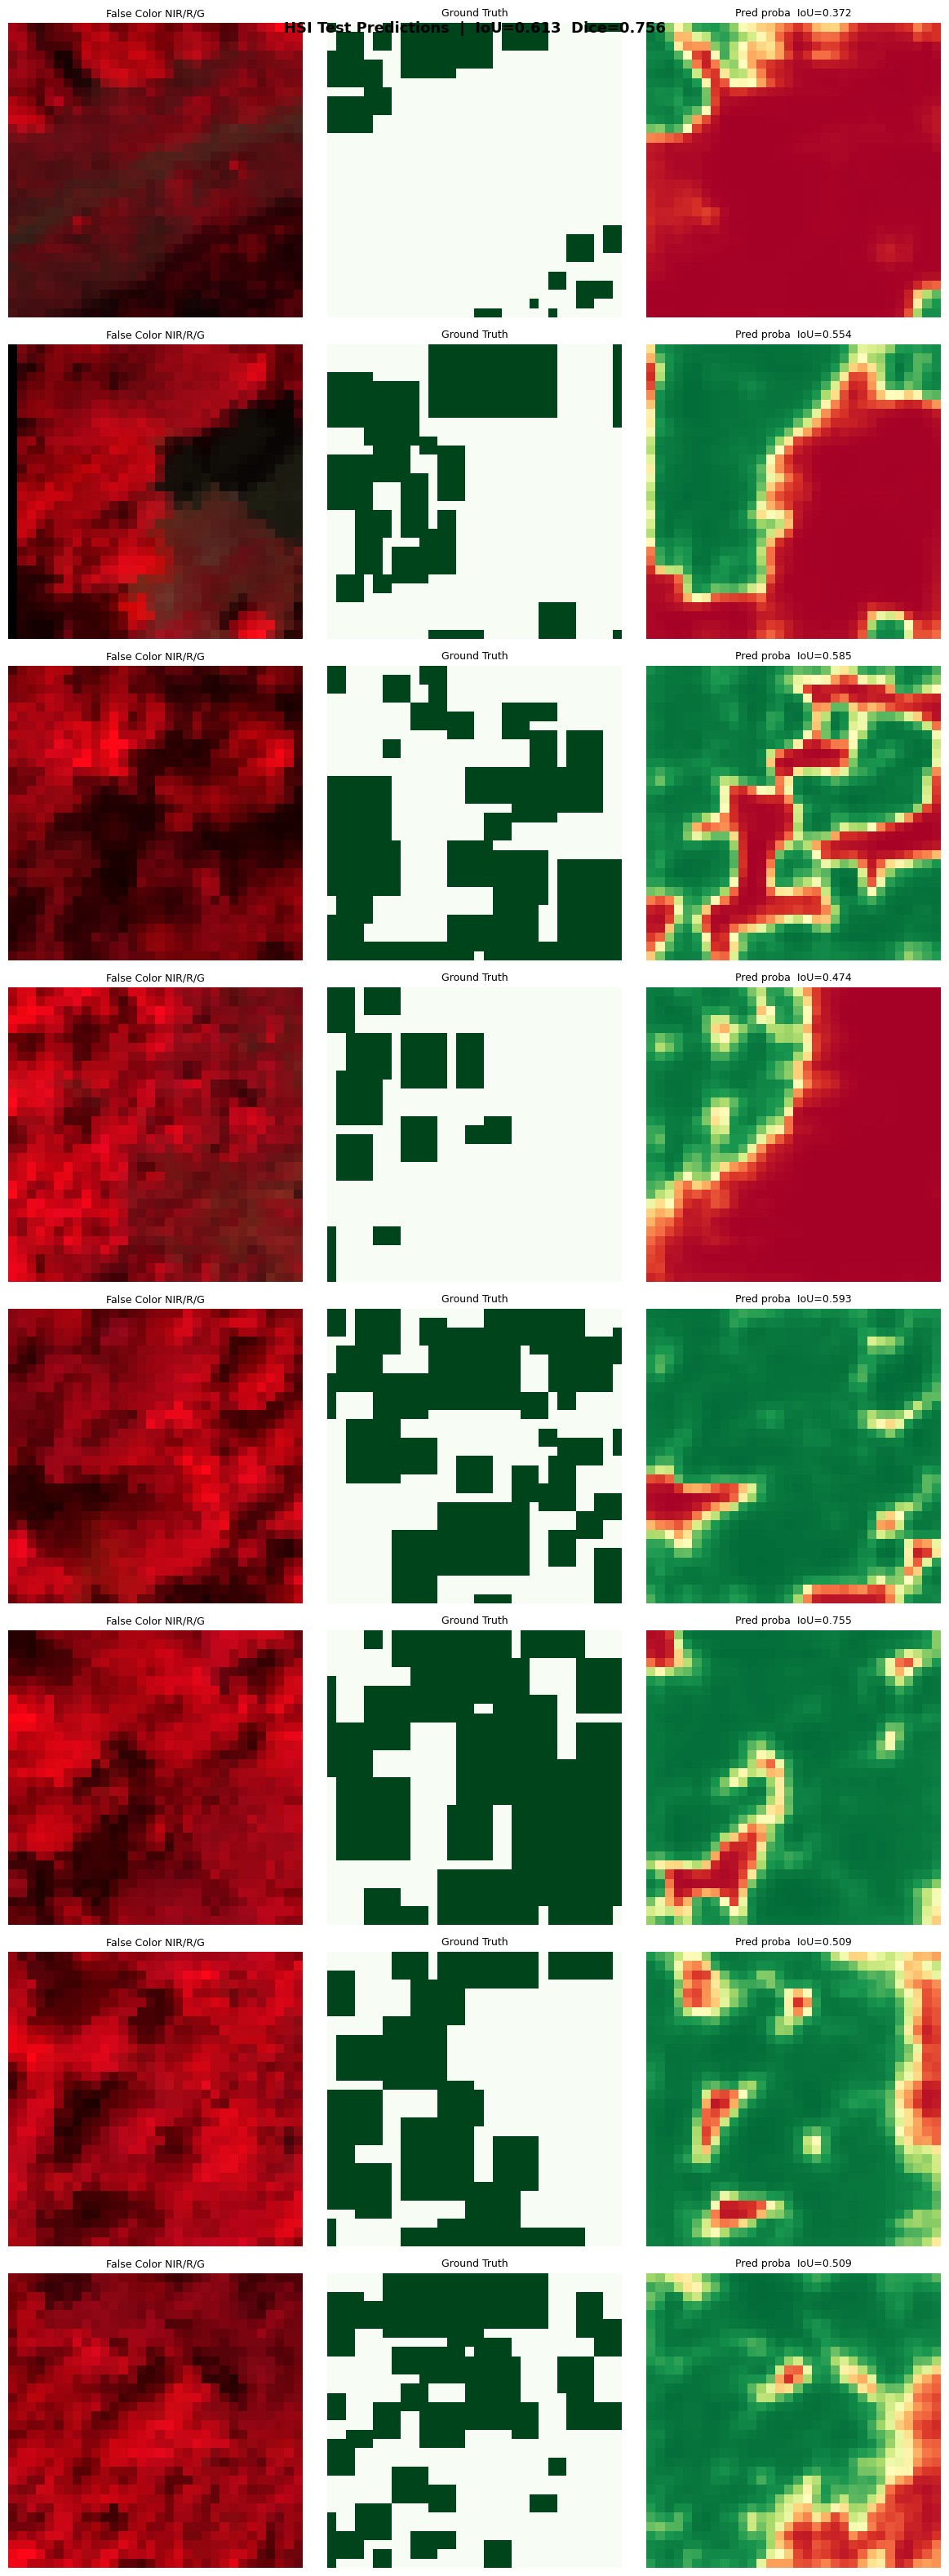

✅ Saved hsi_test_predictions.png  (8 samples with trees shown)


In [25]:
from pathlib import Path

# ── Load best checkpoint ──────────────────────────────────────────────────────
ckpt = torch.load(os.path.join(CFG['save_dir'], 'best_model.pth'), map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()

# ── Build test loader ─────────────────────────────────────────────────────────
root = Path(CFG['preprocessed_dir'])
test_cubes = sorted((root / 'test' / 'img'    / 'tree').glob('*.tif'))
test_masks = sorted((root / 'test' / 'labels' / 'tree').glob('*.tif'))
print(f'Test set: {len(test_cubes)} patches')

test_ds     = HSIDataset(test_cubes, test_masks,
                         augmentation=HSIAugmentation(is_train=False))
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2)

# ── Evaluate on test set ──────────────────────────────────────────────────────
test_loss, test_iou, test_dice = validate(model, test_loader, criterion, DEVICE)
print(f'\n📊 TEST RESULTS')
print(f'   Loss : {test_loss:.4f}')
print(f'   IoU  : {test_iou:.4f}')
print(f'   Dice : {test_dice:.4f}')

# ── Visualize predictions — only samples WITH trees ───────────────────────────
fig, axes = plt.subplots(8, 3, figsize=(12, 32))
plotted = 0

for cubes, masks in test_loader:
    if plotted >= 8:
        break
    with torch.no_grad():
        logits = model(cubes.to(DEVICE))
        probs  = torch.sigmoid(logits).cpu()
        preds  = (probs > 0.5).float()

    for i in range(len(cubes)):
        if plotted >= 8:
            break
        # Only show samples that actually have trees in the mask
        if masks[i].sum() == 0:
            continue

        # False color composite NIR/R/G instead of RGB
        cube_np = cubes[i].cpu().numpy()           # (B, H, W)
        fc = np.stack([cube_np[nir_idx],
                       cube_np[red_idx],
                       cube_np[grn_idx]], axis=-1) # (H, W, 3)
        fc = (fc - fc.min()) / (fc.max() - fc.min() + 1e-6)

        mask_np = masks[i, 0].numpy()
        prob_np = probs[i, 0].numpy()
        iou_val = compute_iou(logits[i:i+1].cpu(), masks[i:i+1])

        axes[plotted, 0].imshow(fc)
        axes[plotted, 0].set_title('False Color NIR/R/G', fontsize=9)
        axes[plotted, 1].imshow(mask_np, cmap='Greens', vmin=0, vmax=1)
        axes[plotted, 1].set_title('Ground Truth', fontsize=9)
        axes[plotted, 2].imshow(prob_np, cmap='RdYlGn', vmin=0, vmax=1)
        axes[plotted, 2].set_title(f'Pred proba  IoU={iou_val:.3f}', fontsize=9)

        for ax in axes[plotted]: ax.axis('off')
        plotted += 1

plt.suptitle(f'HSI Test Predictions  |  IoU={test_iou:.3f}  Dice={test_dice:.3f}',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('hsi_test_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'✅ Saved hsi_test_predictions.png  ({plotted} samples with trees shown)')

## 📈 Cell 10 — Training Curves

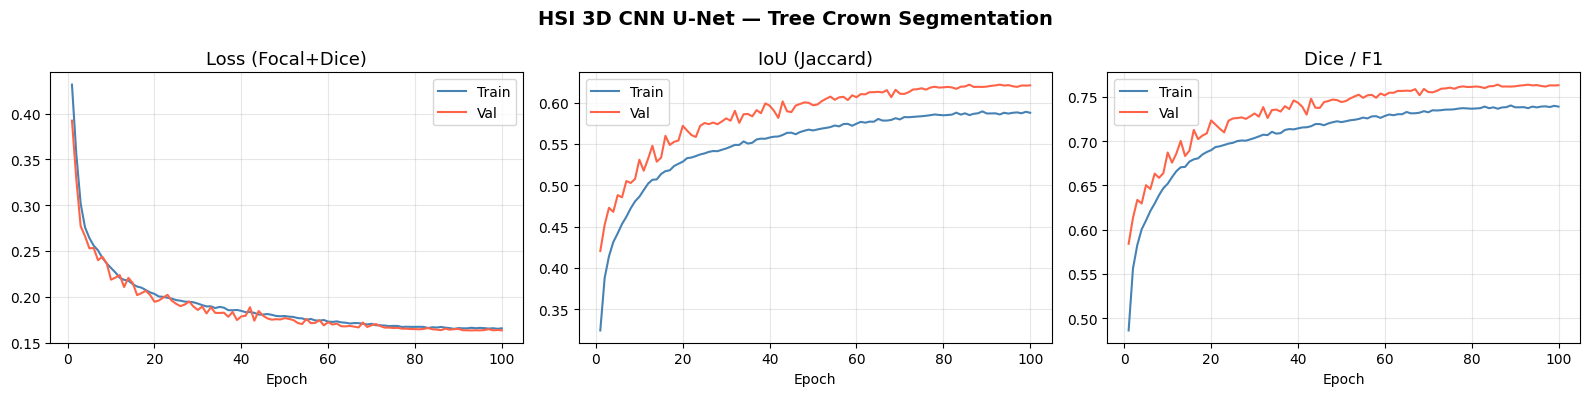

In [26]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, key, title in zip(axes,
    ['loss', 'iou', 'dice'],
    ['Loss (Focal+Dice)', 'IoU (Jaccard)', 'Dice / F1']):
    ax.plot(x, history[f'train_{key}'], label='Train', color='steelblue')
    ax.plot(x, history[f'val_{key}'],   label='Val',   color='tomato')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('HSI 3D CNN U-Net — Tree Crown Segmentation', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('hsi_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 🔬 Cell 11 — Test Set Evaluation & Visualization

/tmp/ipykernel_517635/958106443.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(CFG['save_dir'], 'best_model.pth'), map_location=DEVICE)


Test set: 1278 patches



📊 TEST RESULTS
   Loss : 0.1671
   IoU  : 0.6147
   Dice : 0.7587


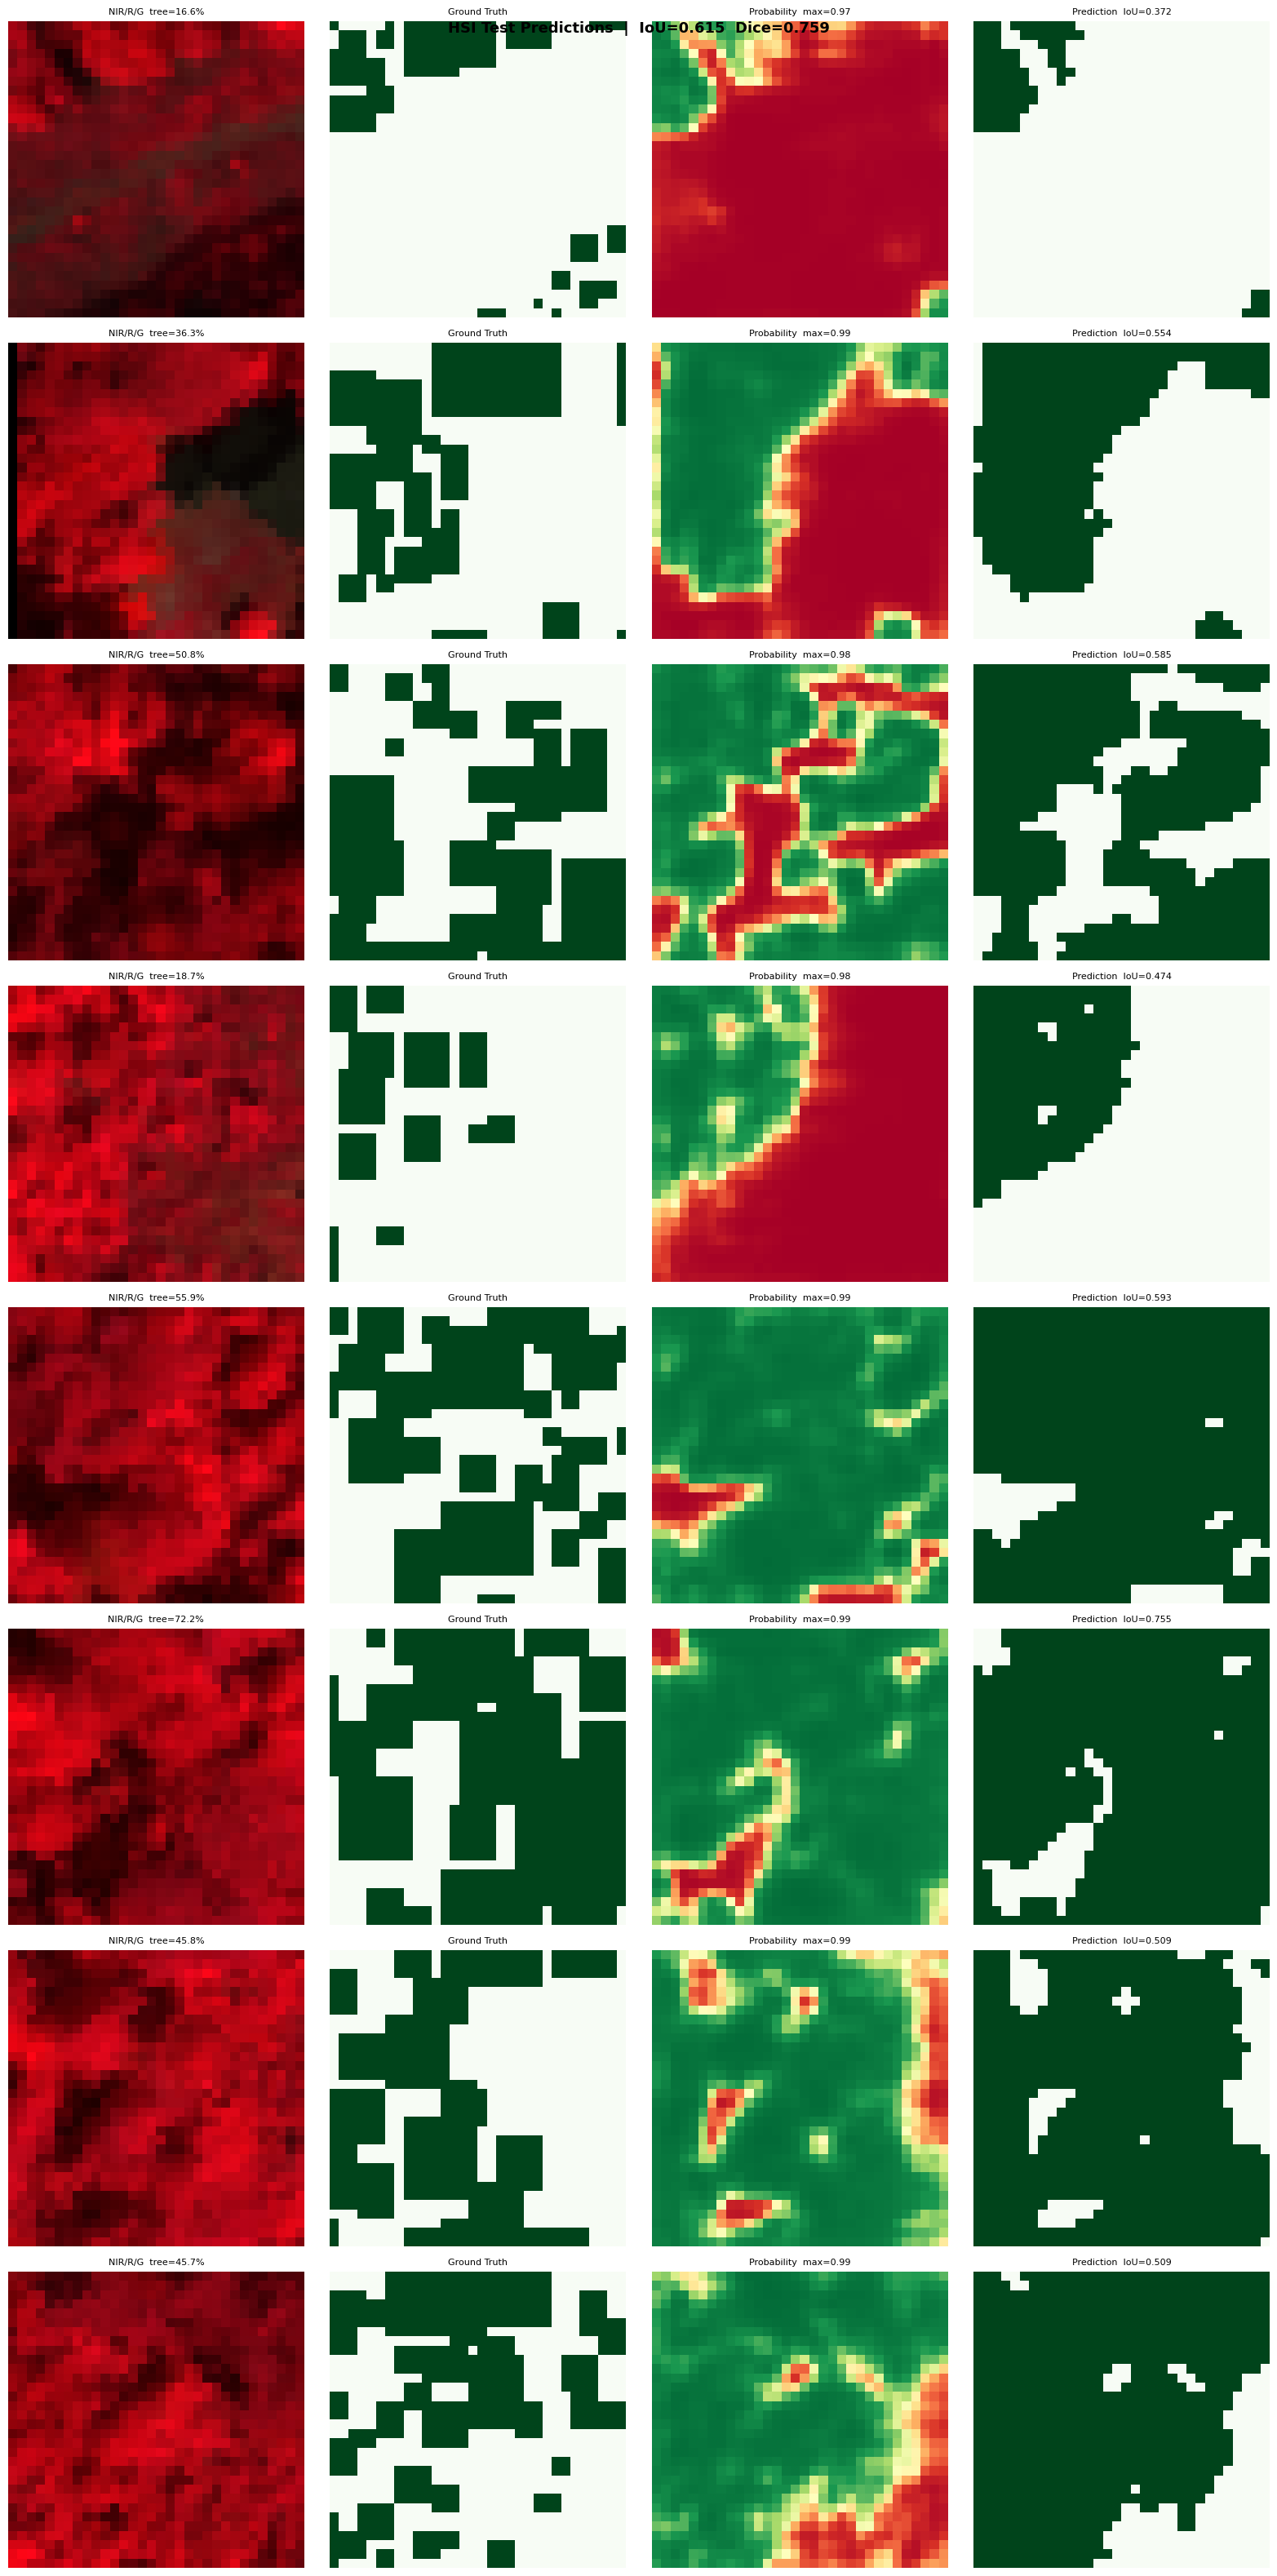

✅ Saved hsi_test_predictions.png


In [27]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
ckpt = torch.load(os.path.join(CFG['save_dir'], 'best_model.pth'), map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()

# ── Build test loader ─────────────────────────────────────────────────────────
root = Path(CFG['preprocessed_dir'])
test_cubes = sorted((root / 'test' / 'img'    / 'tree').glob('*.tif'))
test_masks = sorted((root / 'test' / 'labels' / 'tree').glob('*.tif'))
print(f'Test set: {len(test_cubes)} patches')

test_ds     = HSIDataset(test_cubes, test_masks,
                         augmentation=HSIAugmentation(is_train=False))
test_loader = DataLoader(test_ds, batch_size=CFG['batch_size'],
                         shuffle=False, num_workers=CFG['num_workers'])

# ── Evaluate ──────────────────────────────────────────────────────────────────
test_loss, test_iou, test_dice = validate(model, test_loader, criterion, DEVICE)
print(f'\n📊 TEST RESULTS')
print(f'   Loss : {test_loss:.4f}')
print(f'   IoU  : {test_iou:.4f}')
print(f'   Dice : {test_dice:.4f}')

# ── Visualize: false color | GT | prob map | binary pred ─────────────────────
fig, axes = plt.subplots(8, 4, figsize=(16, 32))
plotted   = 0

for cubes, masks in test_loader:
    if plotted >= 8: break
    with torch.no_grad():
        logits = model(cubes.to(DEVICE))
        probs  = torch.sigmoid(logits).cpu()
        preds  = (probs > 0.5).float()

    for i in range(len(cubes)):
        if plotted >= 8: break
        cube_np = cubes[i].cpu().numpy()
        mask_np = masks[i, 0].numpy()
        prob_np = probs[i, 0].numpy()
        pred_np = preds[i, 0].numpy()

        fc = np.stack([cube_np[nir_idx], cube_np[red_idx], cube_np[grn_idx]], axis=-1)
        fc = (fc - fc.min()) / (fc.max() - fc.min() + 1e-6)

        iou_val  = compute_iou(logits[i:i+1].cpu(), masks[i:i+1])
        tree_pct = mask_np.mean() * 100

        axes[plotted, 0].imshow(fc)
        axes[plotted, 0].set_title(f'NIR/R/G  tree={tree_pct:.1f}%', fontsize=8)
        axes[plotted, 1].imshow(mask_np, cmap='Greens', vmin=0, vmax=1)
        axes[plotted, 1].set_title('Ground Truth', fontsize=8)
        axes[plotted, 2].imshow(prob_np, cmap='RdYlGn', vmin=0, vmax=1)
        axes[plotted, 2].set_title(f'Probability  max={prob_np.max():.2f}', fontsize=8)
        axes[plotted, 3].imshow(pred_np, cmap='Greens', vmin=0, vmax=1)
        axes[plotted, 3].set_title(f'Prediction  IoU={iou_val:.3f}', fontsize=8)
        for ax in axes[plotted]: ax.axis('off')
        plotted += 1

plt.suptitle(f'HSI Test Predictions  |  IoU={test_iou:.3f}  Dice={test_dice:.3f}',
             fontsize=13, fontweight='bold')

plt.tight_layout()

plt.savefig('hsi_test_predictions_Unet_attention.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'✅ Saved hsi_test_predictions.png')

## 💡 Cell 12 — Tips & Next Steps

### Memory issues (3D CNN is heavy):
- Reduce `base_channels` to 8
- Reduce `batch_size` to 8

### Compute actual imbalance ratio:
```python
total_bg, total_tree = 0, 0
for _, mask in train_loader:
    total_tree += mask.sum().item()
    total_bg   += (1 - mask).sum().item()
print(f'pos_weight should be: {total_bg/total_tree:.2f}')
```

### Next: RGB + HSI Fusion
Once both models work independently, fuse at the bottleneck:
```
RGB Attention U-Net encoder
           +
HSI 3D CNN encoder  ->  concat  ->  shared decoder  ->  mask
```